# 머신러닝입문 week04
## 데이터 전처리 II
### 실습

* 회귀는 length를 보고 weight를 맞추는 것
* length가 x축, weight가 y축일 때, y축 평균 데이터가 결과가 되는 것

In [ ]:
import numpy as np

perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5, 44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0, 1000.0])

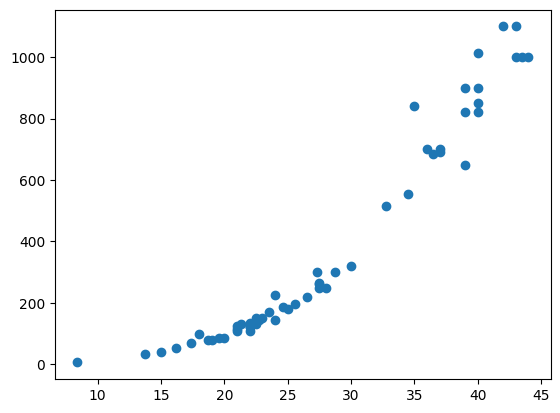

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(perch_length, perch_weight)
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(perch_length, perch_weight, random_state=42)

In [ ]:
train_input.shape, test_input.shape # shape을 꼭 확인해야함, fit 할때 2차원 배열을 넣어야하기 때문

((42,), (14,))

현재 1차원 배열이기 때문에 2차원으로 변경해주어야함.

In [9]:
train_input = train_input.reshape(42, 1) # 길이를 계산하는 대신 -1을 사용하는 방법도 있음
test_input = test_input.reshape(14, 1)
train_input.shape, test_input.shape

((42, 1), (14, 1))

In [10]:
from sklearn.neighbors import KNeighborsRegressor
knr = KNeighborsRegressor()
knr.fit(train_input, train_target)

KNeighborsRegressor()

In [12]:
knr.score(test_input, test_target)

0.992809406101064

테스트 세트의 점수는 **분류에서는 정확도, 회귀에서는 결정계수**

### 길이가 50cm인 농어의 무게를 예측 (k=3)

In [13]:
knr = KNeighborsRegressor(n_neighbors=3)
knr.fit(train_input, train_target)

KNeighborsRegressor(n_neighbors=3)

In [14]:
knr.score(test_input, test_target)

0.9746459963987609

k=5일 떄보다 오히려 정확도가 떨어짐

In [ ]:
knr.predict([[50]]) # fit, predict 중첩 리스트로 넣어주어야함

array([1033.33333333])

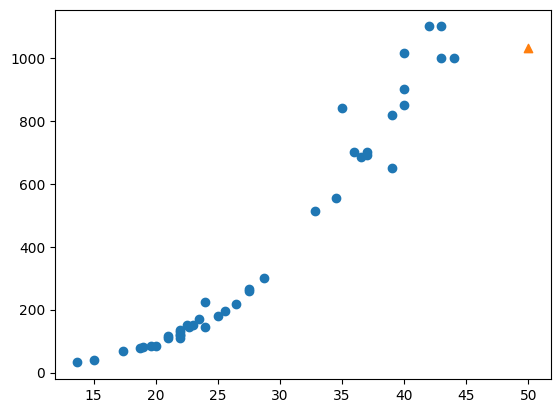

In [16]:
plt.scatter(train_input, train_target)
plt.scatter(50, 1033, marker='^')
plt.show()

* KNN 모델의 단점: 내가 가진 데이터 셋과 전혀 무관한 데이터가 나오면 예측하지 못함
* 길이가 50보다 더 큰 숫자가 나오더라도 계속 같은 데이터가 나옴(길이가 100cm인 농어도 여전히 1,033g으로 예측)